# ..........................PROJECT 01..........................

# * Exploratory Data Analysis (EDA)*
understand the concept of EDA from Basic to Advance 

# EDA on Student Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('student_eda_dataset_3000.csv')

In [3]:
df = data.copy()

In [4]:
df.head()

,Student_ID,Gender,Age,Department,Year,Attendance_Percentage,Study_Hours_Per_Day,Internet_Usage_Hours,Assignments_Completed,Sports_Participation,Hostel_Resident,Family_Income_Level,Exam_Score,CGPA
0,STU10000,Male,18,CE,4,75.1,5.0,8.1,6,No,Yes,Medium,100.0,10.00
1,STU10001,Female,22,BBA,2,88.3,3.7,3.6,9,No,No,High,84.9,7.72
2,STU10002,Male,21,ME,3,91.3,1.8,1.5,0,No,No,Low,68.9,7.42
3,STU10003,Male,25,CSE,1,67.9,4.7,2.9,2,No,Yes,Low,71.8,7.24
4,STU10004,Male,21,ECE,1,77.0,4.5,4.1,2,Yes,Yes,Low,79.5,7.55


Questions to answer
1. How many rows and columns are present?
2. What are the column names?
3. What are the data types?
4. Which columns are numerical?
5. Which columns are categorical?

In [5]:
# Consolidated answers to the 5 questions above
print('1. Rows, Columns:', df.shape)
print('2. Column names:', list(df.columns))
print('3. Data types:\n', df.dtypes)
col_num = [col for col in df.columns if df[col].dtypes in ['int64', 'float64']]
col_cat = [col for col in df.columns if df[col].dtypes not in ['int64', 'float64']]
print('4. Numerical columns:', col_num)
print('5. Categorical columns:', col_cat)

1. Rows, Columns: (3000, 14)
2. Column names: ['Student_ID', 'Gender', 'Age', 'Department', 'Year', 'Attendance_Percentage', 'Study_Hours_Per_Day', 'Internet_Usage_Hours', 'Assignments_Completed', 'Sports_Participation', 'Hostel_Resident', 'Family_Income_Level', 'Exam_Score', 'CGPA']
3. Data types:
 Student_ID                   str
Gender                       str
Age                        int64
Department                   str
Year                       int64
Attendance_Percentage    float64
Study_Hours_Per_Day      float64
Internet_Usage_Hours     float64
Assignments_Completed      int64
Sports_Participation         str
Hostel_Resident              str
Family_Income_Level          str
Exam_Score               float64
CGPA                     float64
dtype: object
4. Numerical columns: ['Age', 'Year', 'Attendance_Percentage', 'Study_Hours_Per_Day', 'Internet_Usage_Hours', 'Assignments_Completed', 'Exam_Score', 'CGPA']
5. Categorical columns: ['Student_ID', 'Gender', 'Department', 'Sp

In [6]:
df.shape

(3000, 14)

In [7]:
cols = df.columns
cols

Index(['Student_ID', 'Gender', 'Age', 'Department', 'Year',
       'Attendance_Percentage', 'Study_Hours_Per_Day', 'Internet_Usage_Hours',
       'Assignments_Completed', 'Sports_Participation', 'Hostel_Resident',
       'Family_Income_Level', 'Exam_Score', 'CGPA'],
      dtype='str')

In [8]:
df.dtypes

Student_ID                   str
Gender                       str
Age                        int64
Department                   str
Year                       int64
Attendance_Percentage    float64
Study_Hours_Per_Day      float64
Internet_Usage_Hours     float64
Assignments_Completed      int64
Sports_Participation         str
Hostel_Resident              str
Family_Income_Level          str
Exam_Score               float64
CGPA                     float64
dtype: object

In [9]:
col_num = []
for col in df.columns:
    if df[col].dtypes in ['int64', 'float64']:
        col_num.append(col)

In [10]:
col_num

['Age',
 'Year',
 'Attendance_Percentage',
 'Study_Hours_Per_Day',
 'Internet_Usage_Hours',
 'Assignments_Completed',
 'Exam_Score',
 'CGPA']

In [11]:
col_num = [col for col in df.columns if df[col].dtypes in ['int64', 'float64']]
col_num

['Age',
 'Year',
 'Attendance_Percentage',
 'Study_Hours_Per_Day',
 'Internet_Usage_Hours',
 'Assignments_Completed',
 'Exam_Score',
 'CGPA']

In [12]:
col_cat = [col for col in df.columns if df[col].dtypes not in ['int64', 'float64']]
col_cat

['Student_ID',
 'Gender',
 'Department',
 'Sports_Participation',
 'Hostel_Resident',
 'Family_Income_Level']

In [13]:
df['Gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [14]:
male, Male, M, m, female , Female, FEMALE

NameError: name 'male' is not defined

In [15]:
for col in col_cat:
    if col != 'Student_ID':
        print(f'feature {col} {df[col].unique()}')

feature Gender <StringArray>
['Male', 'Female']
Length: 2, dtype: str
feature Department <StringArray>
['CE', 'BBA', 'ME', 'CSE', 'ECE', 'EEE']
Length: 6, dtype: str
feature Sports_Participation <StringArray>
['No', 'Yes']
Length: 2, dtype: str
feature Hostel_Resident <StringArray>
['Yes', 'No']
Length: 2, dtype: str
feature Family_Income_Level <StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str


In [16]:
print("Number of unique categories per categorical column:")
for col in col_cat:
    if col != 'Student_ID':
        print(f"{col}: {df[col].nunique()} unique values")

Number of unique categories per categorical column:
Gender: 2 unique values
Department: 6 unique values
Sports_Participation: 2 unique values
Hostel_Resident: 2 unique values
Family_Income_Level: 3 unique values


Missing Value Analysis

Check data quality.

Questions
1. Are there missing values?
2. Which columns contain missing values?
3. What percentage of data is missing?

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             3000 non-null   str    
 1   Gender                 3000 non-null   str    
 2   Age                    3000 non-null   int64  
 3   Department             3000 non-null   str    
 4   Year                   3000 non-null   int64  
 5   Attendance_Percentage  3000 non-null   float64
 6   Study_Hours_Per_Day    3000 non-null   float64
 7   Internet_Usage_Hours   3000 non-null   float64
 8   Assignments_Completed  3000 non-null   int64  
 9   Sports_Participation   3000 non-null   str    
 10  Hostel_Resident        3000 non-null   str    
 11  Family_Income_Level    3000 non-null   str    
 12  Exam_Score             3000 non-null   float64
 13  CGPA                   3000 non-null   float64
dtypes: float64(5), int64(3), str(6)
memory usage: 328.3 KB


In [18]:
df.isnull().sum()

Student_ID               0
Gender                   0
Age                      0
Department               0
Year                     0
Attendance_Percentage    0
Study_Hours_Per_Day      0
Internet_Usage_Hours     0
Assignments_Completed    0
Sports_Participation     0
Hostel_Resident          0
Family_Income_Level      0
Exam_Score               0
CGPA                     0
dtype: int64

In [19]:
(df.isnull().sum()/len(df))*100

Student_ID               0.0
Gender                   0.0
Age                      0.0
Department               0.0
Year                     0.0
Attendance_Percentage    0.0
Study_Hours_Per_Day      0.0
Internet_Usage_Hours     0.0
Assignments_Completed    0.0
Sports_Participation     0.0
Hostel_Resident          0.0
Family_Income_Level      0.0
Exam_Score               0.0
CGPA                     0.0
dtype: float64

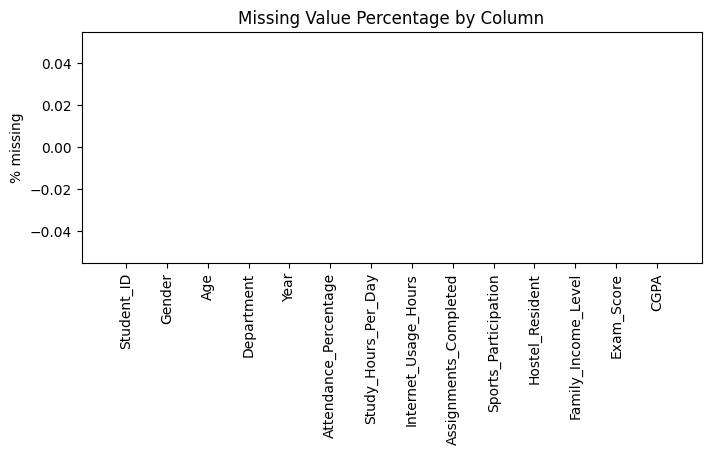

Conclusion: There are no missing values in any column.


In [20]:
missing_pct = (df.isnull().sum()/len(df))*100
plt.figure(figsize=(8,3))
plt.bar(missing_pct.index, missing_pct.values)
plt.xticks(rotation=90)
plt.ylabel('% missing')
plt.title('Missing Value Percentage by Column')
plt.show()

print("Conclusion: There are no missing values in any column." if missing_pct.sum()==0
      else "Conclusion: Some columns contain missing values, see chart above.")

Duplicate Analysis
Questions
1. Are duplicate rows present?
2. How many duplicates exist?

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
dup_count = df.duplicated().sum()
print(f"Number of duplicate rows: {dup_count}")
if dup_count > 0:
    display(df[df.duplicated()])
else:
    print("Conclusion: No duplicate rows are present in the dataset.")

Number of duplicate rows: 0
Conclusion: No duplicate rows are present in the dataset.


Descriptive Statistics
Numerical Variables
* Mean
* Median
* Standard deviation
* Minimum
* Maximum
* Quartiles

In [23]:
df.describe()

,Age,Year,Attendance_Percentage,Study_Hours_Per_Day,Internet_Usage_Hours,Assignments_Completed,Exam_Score,CGPA
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,21.008667,2.466000,79.868667,3.478633,4.066533,5.048000,82.918500,8.260397
std,2.560620,1.125729,9.806451,1.487886,1.901460,3.128198,11.743549,1.213098
min,17.000000,1.000000,45.900000,0.500000,0.500000,0.000000,42.600000,4.050000
25%,19.000000,1.000000,73.300000,2.400000,2.700000,2.000000,75.200000,7.420000
50%,21.000000,2.000000,79.800000,3.500000,4.000000,5.000000,83.800000,8.370000
75%,23.000000,3.000000,86.700000,4.500000,5.300000,8.000000,92.025000,9.240000
max,25.000000,4.000000,100.000000,8.200000,10.400000,10.000000,100.000000,10.000000


Univariate Analysis

Study one variable at a time.

Numerical Columns
* Age
* Attendance_Percentage
* Study_Hours_Per_Day
* Internet_Usage_Hours
* Assignments_Completed
* Exam_Score
* CGPA

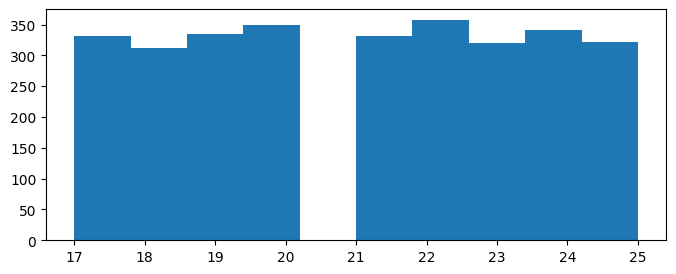

In [24]:
plt.figure(figsize=(8,3))
plt.hist(df['Age'])
plt.show()

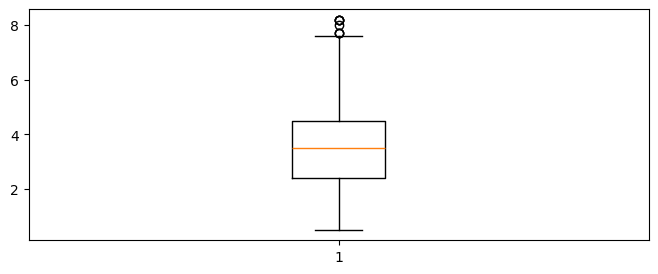

In [25]:
plt.figure(figsize=(8,3))
plt.boxplot(df['Study_Hours_Per_Day'])
plt.show()

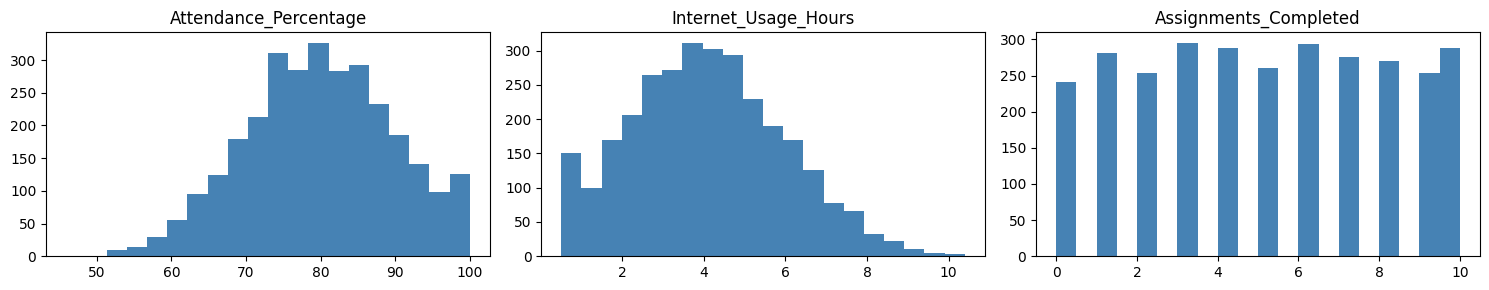

In [26]:
num_cols_rest = ['Attendance_Percentage', 'Internet_Usage_Hours', 'Assignments_Completed']
fig, axes = plt.subplots(1, 3, figsize=(15,3))
for ax, col in zip(axes, num_cols_rest):
    ax.hist(df[col], bins=20, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

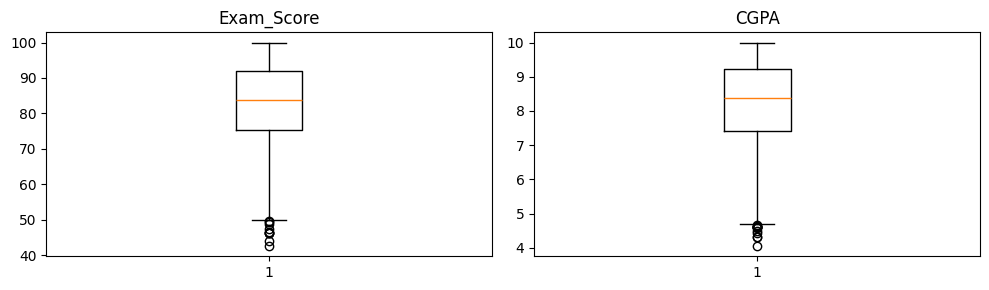

In [27]:
num_cols_rest2 = ['Exam_Score', 'CGPA']
fig, axes = plt.subplots(1, 2, figsize=(10,3))
for ax, col in zip(axes, num_cols_rest2):
    ax.boxplot(df[col])
    ax.set_title(col)
plt.tight_layout()
plt.show()

Categorical Columns
* Gender
* Department
* Sports_Participation
* Hostel_Resident
* Family_Income_Level

In [28]:
for col in col_cat:
    if col != 'Student_ID':
        print(f'feature {col} {df[col].value_counts()}')
        print('......................')

feature Gender Gender
Male      1517
Female    1483
Name: count, dtype: int64
......................
feature Department Department
ECE    559
EEE    508
CSE    485
BBA    484
ME     483
CE     481
Name: count, dtype: int64
......................
feature Sports_Participation Sports_Participation
No     1644
Yes    1356
Name: count, dtype: int64
......................
feature Hostel_Resident Hostel_Resident
No     1808
Yes    1192
Name: count, dtype: int64
......................
feature Family_Income_Level Family_Income_Level
Medium    1523
Low        854
High       623
Name: count, dtype: int64
......................


In [29]:
# create here a graph for all the categories

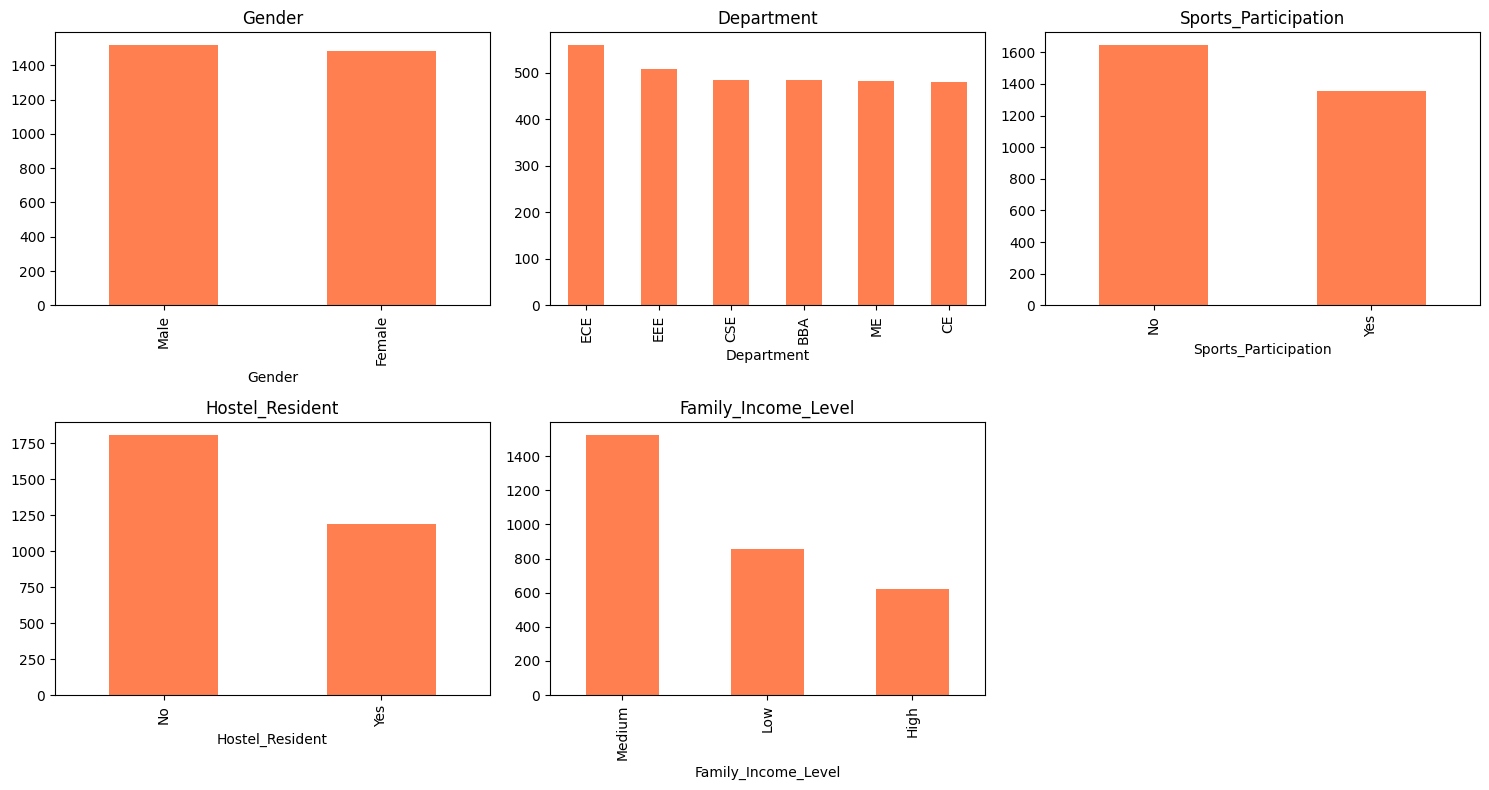

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()
cat_plot_cols = [c for c in col_cat if c != 'Student_ID']
for ax, col in zip(axes, cat_plot_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, color='coral')
    ax.set_title(col)
for ax in axes[len(cat_plot_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

In [31]:
# find the male students who study more than avg hours
male_stu_hour= df[
    (df['Gender']=='Male') & (df['Study_Hours_Per_Day']> df['Study_Hours_Per_Day'].mean() )
].shape[0]
male_stu_hour

787

In [32]:
z= df.groupby('Department')

In [33]:
z

In [34]:
department_maxes = df.groupby("Department")["Exam_Score"].max()

In [35]:
department_maxes

Department
BBA    100.0
CE     100.0
CSE    100.0
ECE    100.0
EEE    100.0
ME     100.0
Name: Exam_Score, dtype: float64

In [36]:
# figure out the students whos exam score is max from each dept
student_max_from_dept = df[
    df['Exam_Score'] == df.groupby('Department')['Exam_Score'].transform('max')
]
student_max_from_dept.head()

,Student_ID,Gender,Age,Department,Year,Attendance_Percentage,Study_Hours_Per_Day,Internet_Usage_Hours,Assignments_Completed,Sports_Participation,Hostel_Resident,Family_Income_Level,Exam_Score,CGPA
0,STU10000,Male,18,CE,4,75.1,5.0,8.1,6,No,Yes,Medium,100.0,10.00
7,STU10007,Male,20,CSE,2,85.3,5.2,2.2,9,Yes,No,Low,100.0,10.00
29,STU10029,Female,18,ME,3,84.8,3.6,7.7,8,No,No,Low,100.0,10.00
40,STU10040,Male,20,CE,4,63.0,5.5,1.2,10,No,No,Medium,100.0,9.71
42,STU10042,Female,20,EEE,2,73.8,6.0,6.2,10,No,Yes,Low,100.0,10.00


In [37]:
d_max = df.groupby("Department")["Exam_Score"].transform("max")
df[df["Exam_Score"] == d_max.max() ]

,Student_ID,Gender,Age,Department,Year,Attendance_Percentage,Study_Hours_Per_Day,Internet_Usage_Hours,Assignments_Completed,Sports_Participation,Hostel_Resident,Family_Income_Level,Exam_Score,CGPA
0,STU10000,Male,18,CE,4,75.1,5.0,8.1,6,No,Yes,Medium,100.0,10.00
7,STU10007,Male,20,CSE,2,85.3,5.2,2.2,9,Yes,No,Low,100.0,10.00
29,STU10029,Female,18,ME,3,84.8,3.6,7.7,8,No,No,Low,100.0,10.00
40,STU10040,Male,20,CE,4,63.0,5.5,1.2,10,No,No,Medium,100.0,9.71
42,STU10042,Female,20,EEE,2,73.8,6.0,6.2,10,No,Yes,Low,100.0,10.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2976,STU12976,Female,19,BBA,4,81.8,5.4,3.2,6,No,No,Low,100.0,10.00
2978,STU12978,Male,23,ECE,2,70.5,4.8,1.5,10,Yes,Yes,High,100.0,10.00
2981,STU12981,Female,19,ME,2,78.4,4.4,6.3,10,Yes,Yes,Low,100.0,8.91
2992,STU12992,Female,17,ECE,3,81.6,4.3,5.8,9,No,No,Medium,100.0,9.51


In [38]:
# figure out the students whos exam score is max from each dept
# figure out the students whos exam score is max from each dept
student_max_from_dept = df[
    df['Exam_Score'] == df.groupby('Department')['Exam_Score'].transform('max')
]
student_max_from_dept.head()

,Student_ID,Gender,Age,Department,Year,Attendance_Percentage,Study_Hours_Per_Day,Internet_Usage_Hours,Assignments_Completed,Sports_Participation,Hostel_Resident,Family_Income_Level,Exam_Score,CGPA
0,STU10000,Male,18,CE,4,75.1,5.0,8.1,6,No,Yes,Medium,100.0,10.00
7,STU10007,Male,20,CSE,2,85.3,5.2,2.2,9,Yes,No,Low,100.0,10.00
29,STU10029,Female,18,ME,3,84.8,3.6,7.7,8,No,No,Low,100.0,10.00
40,STU10040,Male,20,CE,4,63.0,5.5,1.2,10,No,No,Medium,100.0,9.71
42,STU10042,Female,20,EEE,2,73.8,6.0,6.2,10,No,Yes,Low,100.0,10.00


In [39]:
df['Department'].idxmax()

2

In [40]:
ind = df.groupby("Department")["Exam_Score"].idxmax()
df.loc[ind]

,Student_ID,Gender,Age,Department,Year,Attendance_Percentage,Study_Hours_Per_Day,Internet_Usage_Hours,Assignments_Completed,Sports_Participation,Hostel_Resident,Family_Income_Level,Exam_Score,CGPA
69,STU10069,Female,19,BBA,1,76.7,5.6,3.6,2,Yes,No,Medium,100.0,10.00
0,STU10000,Male,18,CE,4,75.1,5.0,8.1,6,No,Yes,Medium,100.0,10.00
7,STU10007,Male,20,CSE,2,85.3,5.2,2.2,9,Yes,No,Low,100.0,10.00
50,STU10050,Male,22,ECE,2,87.5,6.1,3.8,5,Yes,No,High,100.0,8.99
42,STU10042,Female,20,EEE,2,73.8,6.0,6.2,10,No,Yes,Low,100.0,10.00
29,STU10029,Female,18,ME,3,84.8,3.6,7.7,8,No,No,Low,100.0,10.00


In [41]:
# filter out the students residing in hostel , they having the max score from each dept

In [42]:
hostel_students = df[df['Hostel_Resident']=='Yes']
hostel_students.shape[0]

1192

In [43]:
index = hostel_students.groupby('Department')['Exam_Score'].idxmax()

In [44]:
hostel_students.loc[index]

,Student_ID,Gender,Age,Department,Year,Attendance_Percentage,Study_Hours_Per_Day,Internet_Usage_Hours,Assignments_Completed,Sports_Participation,Hostel_Resident,Family_Income_Level,Exam_Score,CGPA
241,STU10241,Male,23,BBA,3,94.6,5.7,6.5,6,Yes,Yes,Medium,100.0,10.00
0,STU10000,Male,18,CE,4,75.1,5.0,8.1,6,No,Yes,Medium,100.0,10.00
124,STU10124,Male,24,CSE,3,97.9,5.0,7.2,6,No,Yes,Medium,100.0,10.00
66,STU10066,Female,23,ECE,2,84.8,3.6,1.6,9,No,Yes,Low,100.0,9.91
42,STU10042,Female,20,EEE,2,73.8,6.0,6.2,10,No,Yes,Low,100.0,10.00
106,STU10106,Female,24,ME,1,81.2,5.9,6.0,10,No,Yes,Low,100.0,9.77


In [45]:
# Compare hostel residents vs non-residents in terms of top performance
non_hostel_students = df[df['Hostel_Resident']=='No']
print("Average Exam Score - Hostel residents:", round(hostel_students['Exam_Score'].mean(),2))
print("Average Exam Score - Non-hostel residents:", round(non_hostel_students['Exam_Score'].mean(),2))

Average Exam Score - Hostel residents: 82.6
Average Exam Score - Non-hostel residents: 83.13


Study Hours vs Exam Score

Questions:

1. Does studying more improve marks?
2. Is the relationship linear?

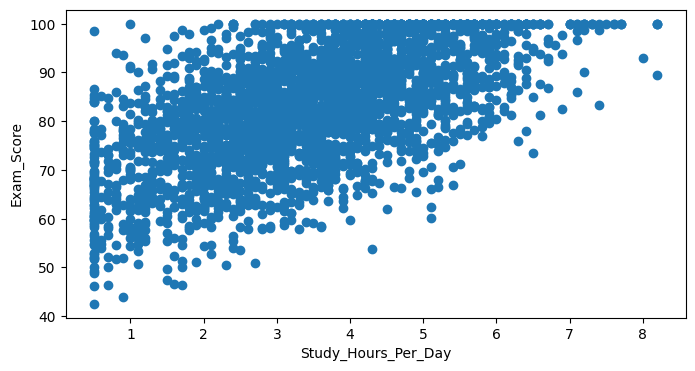

In [46]:
plt.figure(figsize=(8,4))
plt.scatter(df['Study_Hours_Per_Day'],df['Exam_Score'])
plt.xlabel('Study_Hours_Per_Day')
plt.ylabel('Exam_Score')
plt.show()

In [47]:
corr_study_exam = df['Study_Hours_Per_Day'].corr(df['Exam_Score'])
print(f"Correlation between Study Hours and Exam Score: {corr_study_exam:.3f}")
print("A weak/near-zero correlation suggests studying more does not show a strong linear improvement in marks."
      if abs(corr_study_exam) < 0.3 else
      "A noticeable correlation suggests studying more is associated with better marks.")

Correlation between Study Hours and Exam Score: 0.596
A noticeable correlation suggests studying more is associated with better marks.


Attendance vs Exam Score

Questions:

1. Does attendance affect performance?

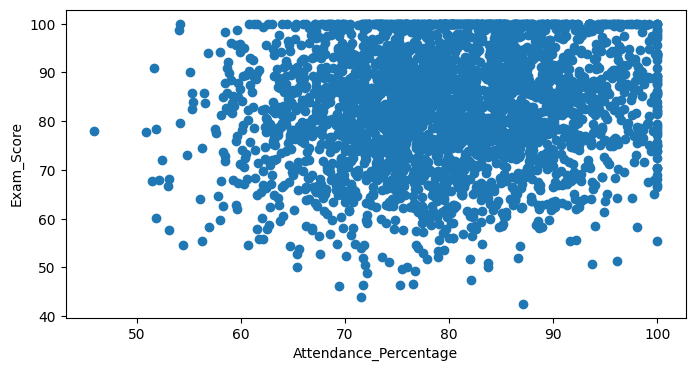

In [48]:
plt.figure(figsize=(8,4))
plt.scatter(df['Attendance_Percentage'],df['Exam_Score'])
plt.xlabel('Attendance_Percentage')
plt.ylabel('Exam_Score')
plt.show()

In [49]:
corr_att_exam = df['Attendance_Percentage'].corr(df['Exam_Score'])
print(f"Correlation between Attendance and Exam Score: {corr_att_exam:.3f}")
print("Attendance shows little linear relationship with performance."
      if abs(corr_att_exam) < 0.3 else
      "Attendance appears to be associated with exam performance.")

Correlation between Attendance and Exam Score: 0.132
Attendance shows little linear relationship with performance.


Exam Score vs CGPA

Questions:

1. Are they strongly correlated?

In [50]:
df['Exam_Score'].corr(df['CGPA'])  # negative , 0 , Positive

np.float64(0.9221569384576683)

In [51]:
study hour cgpa

SyntaxError: invalid syntax (3881535395.py, line 1)

Internet Usage vs Exam Score

Questions:

1. Does excessive internet usage reduce marks?

In [52]:
bins = [0, 2, 4, 6, 8, 12]
labels = ['very low','low','moderate','High','V High']
df['internet_cat'] = pd.cut(
    df['Internet_Usage_Hours'], 
    bins = bins,
    labels = labels
)

avg_score = df.groupby('internet_cat')['Exam_Score'].mean()
avg_score

internet_cat
very low    83.211663
low         82.952470
moderate    82.681187
High        83.226933
V High      82.049275
Name: Exam_Score, dtype: float64

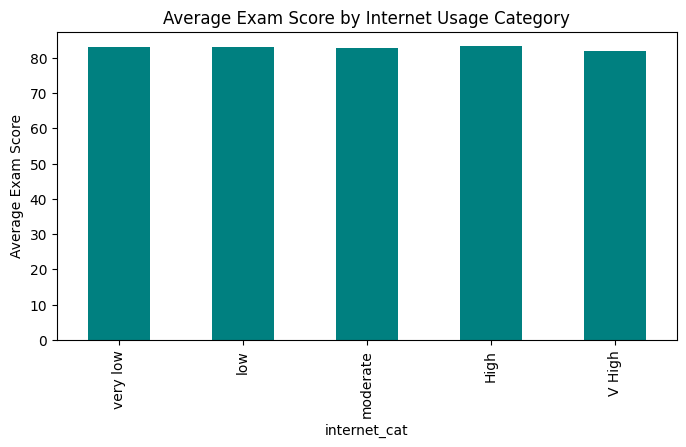

In [53]:
plt.figure(figsize=(8,4))
avg_score.plot(kind='bar', color='teal')
plt.ylabel('Average Exam Score')
plt.title('Average Exam Score by Internet Usage Category')
plt.show()

Age vs CGPA

Questions:

1. Is age related to performance?

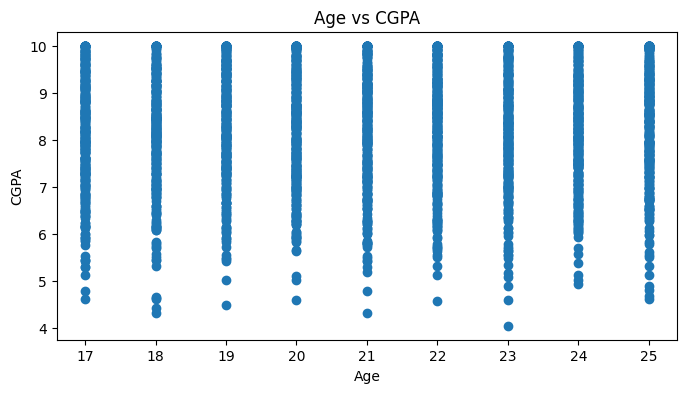

In [54]:
plt.figure(figsize=(8,4))
plt.scatter(df['Age'], df['CGPA'])
plt.xlabel('Age')
plt.ylabel('CGPA')
plt.title('Age vs CGPA')
plt.show()

In [55]:
corr_age_cgpa = df['Age'].corr(df['CGPA'])
print(f"Correlation between Age and CGPA: {corr_age_cgpa:.3f}")
print("Age does not show a meaningful relationship with CGPA." if abs(corr_age_cgpa) < 0.1
      else "Age shows some relationship with CGPA.")

Correlation between Age and CGPA: 0.017
Age does not show a meaningful relationship with CGPA.


Department vs CGPA

Question:

1. Which department has the highest average CGPA?

In [56]:
dept_cgpa = df.groupby('Department')['CGPA'].mean().sort_values(ascending=False)
dept_cgpa

Department
ME     8.295776
ECE    8.288730
CSE    8.281711
BBA    8.258843
EEE    8.257303
CE     8.175281
Name: CGPA, dtype: float64

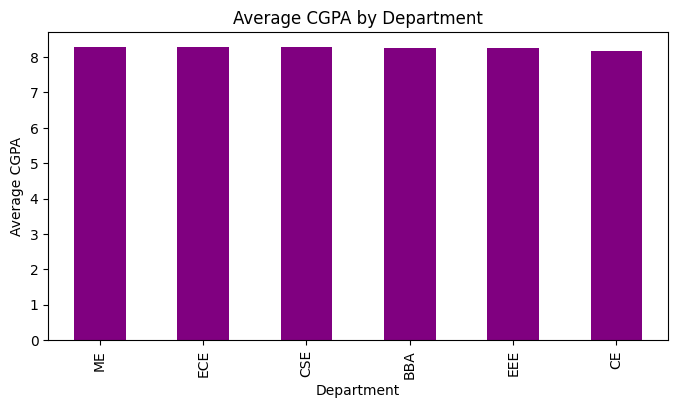

Department with highest average CGPA: ME (8.30)


In [57]:
plt.figure(figsize=(8,4))
dept_cgpa.plot(kind='bar', color='purple')
plt.ylabel('Average CGPA')
plt.title('Average CGPA by Department')
plt.show()
print(f"Department with highest average CGPA: {dept_cgpa.idxmax()} ({dept_cgpa.max():.2f})")

Gender vs Exam Score

Question:

1.Do males and females perform differently?

Gender
Female    82.841605
Male      82.993672
Name: Exam_Score, dtype: float64


<Figure size 600x400 with 0 Axes>

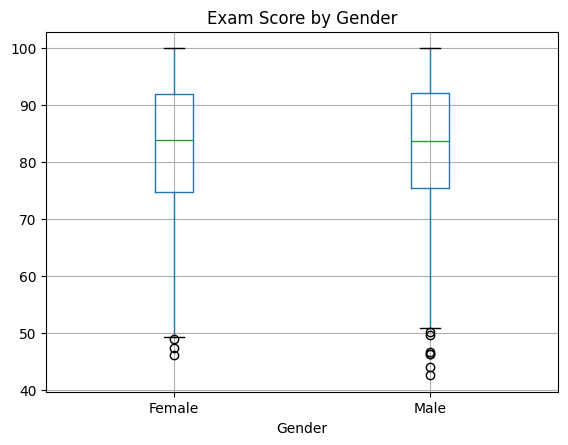

In [58]:
gender_score = df.groupby('Gender')['Exam_Score'].mean()
print(gender_score)

plt.figure(figsize=(6,4))
df.boxplot(column='Exam_Score', by='Gender')
plt.title('Exam Score by Gender')
plt.suptitle('')
plt.show()

Family Income vs CGPA

Question:

1. Does economic status affect academic performance?

In [59]:
income_cgpa = df.groupby('Family_Income_Level')['CGPA'].mean().sort_values(ascending=False)
income_cgpa

Family_Income_Level
Medium    8.280112
Low       8.271499
High      8.196982
Name: CGPA, dtype: float64

<Figure size 600x400 with 0 Axes>

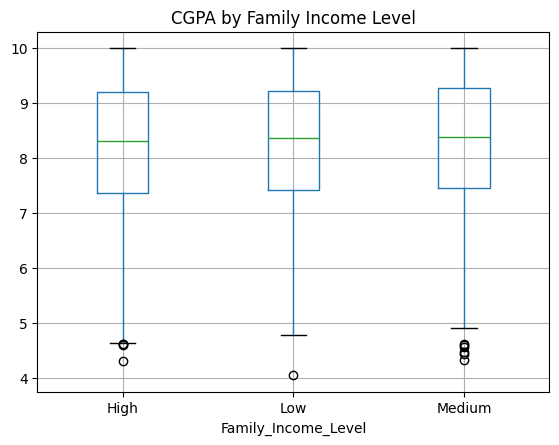

In [60]:
plt.figure(figsize=(6,4))
df.boxplot(column='CGPA', by='Family_Income_Level')
plt.title('CGPA by Family Income Level')
plt.suptitle('')
plt.show()

Hostel Resident vs Exam Score

Question:

1. Do hostel students score higher?

Hostel_Resident
No     83.131416
Yes    82.595554
Name: Exam_Score, dtype: float64


<Figure size 600x400 with 0 Axes>

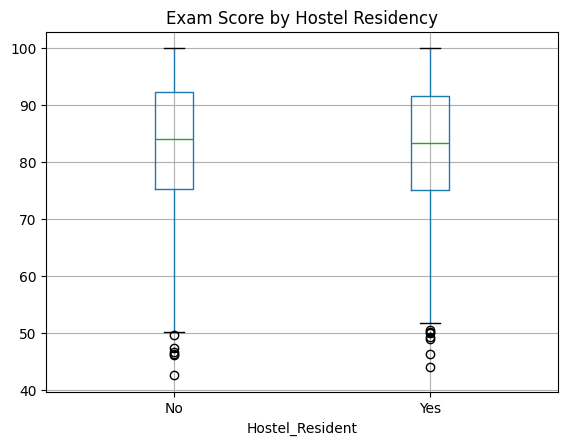

In [61]:
hostel_score = df.groupby('Hostel_Resident')['Exam_Score'].mean()
print(hostel_score)

plt.figure(figsize=(6,4))
df.boxplot(column='Exam_Score', by='Hostel_Resident')
plt.title('Exam Score by Hostel Residency')
plt.suptitle('')
plt.show()

Sports Participation vs CGPA

Question:

1. Does participation in sports influence academic performance?

In [62]:
sports_cgpa = df.groupby('Sports_Participation')['CGPA'].mean()
sports_cgpa

Sports_Participation
No     8.254185
Yes    8.267928
Name: CGPA, dtype: float64

<Figure size 600x400 with 0 Axes>

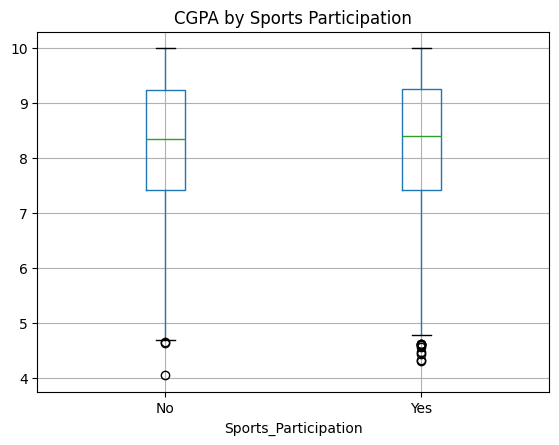

In [63]:
plt.figure(figsize=(6,4))
df.boxplot(column='CGPA', by='Sports_Participation')
plt.title('CGPA by Sports Participation')
plt.suptitle('')
plt.show()

Find correlation
Questions:

1. Which features have strong positive correlation with Exam Score?
2. Which features have weak correlation?
3. Are there highly correlated variables?

In [64]:
corr_matrix = df[col_num].corr()
corr_with_exam = corr_matrix['Exam_Score'].sort_values(ascending=False)
corr_with_exam

Exam_Score               1.000000
CGPA                     0.922157
Study_Hours_Per_Day      0.595833
Assignments_Completed    0.493760
Attendance_Percentage    0.131876
Age                      0.017686
Year                    -0.010850
Internet_Usage_Hours    -0.015691
Name: Exam_Score, dtype: float64

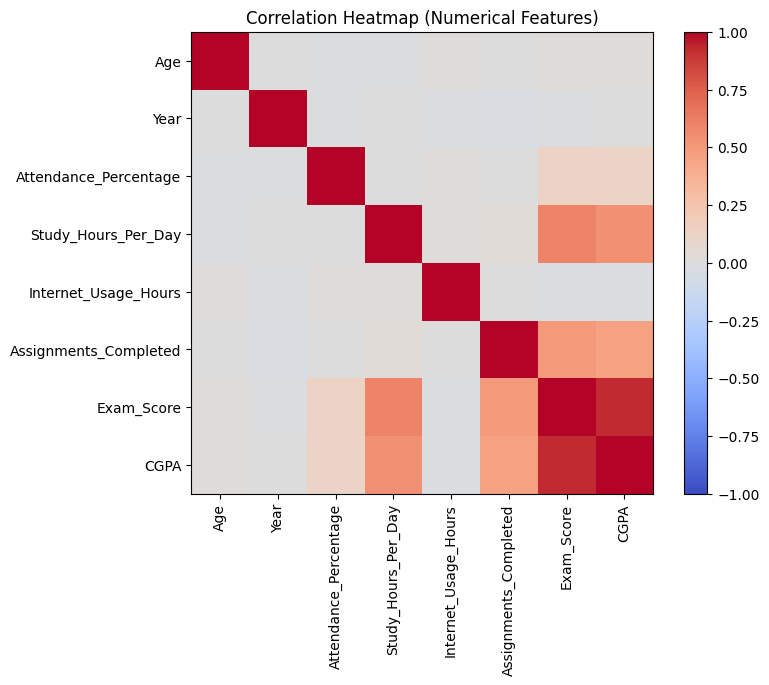

In [65]:
plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title('Correlation Heatmap (Numerical Features)')
plt.show()

outliers 
Questions:

1. Are there students with exceptionally high or low marks?
2. Are there abnormal study hours?

In [66]:
# Outliers in Exam_Score using IQR method
Q1 = df['Exam_Score'].quantile(0.25)
Q3 = df['Exam_Score'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
exam_outliers = df[(df['Exam_Score'] < lower) | (df['Exam_Score'] > upper)]
print(f"Number of Exam Score outliers: {exam_outliers.shape[0]}")
exam_outliers.head()

Number of Exam Score outliers: 10


,Student_ID,Gender,Age,Department,Year,Attendance_Percentage,Study_Hours_Per_Day,Internet_Usage_Hours,Assignments_Completed,Sports_Participation,Hostel_Resident,Family_Income_Level,Exam_Score,CGPA,internet_cat
61,STU10061,Male,20,ECE,2,76.5,1.6,7.0,0,No,No,Medium,46.7,5.03,High
73,STU10073,Female,18,CSE,1,69.4,0.5,3.3,3,Yes,No,Medium,46.2,4.32,low
692,STU10692,Male,20,CE,1,75.3,1.7,5.3,1,Yes,No,High,46.4,4.60,moderate
1218,STU11218,Male,18,ME,1,71.7,0.7,3.5,2,Yes,Yes,Medium,46.4,4.62,low
1482,STU11482,Female,18,ECE,4,72.1,0.5,3.8,2,No,Yes,High,48.9,4.64,low


In [67]:
# Outliers in Study_Hours_Per_Day using IQR method
Q1s = df['Study_Hours_Per_Day'].quantile(0.25)
Q3s = df['Study_Hours_Per_Day'].quantile(0.75)
IQRs = Q3s - Q1s
lowers, uppers = Q1s - 1.5*IQRs, Q3s + 1.5*IQRs
study_outliers = df[(df['Study_Hours_Per_Day'] < lowers) | (df['Study_Hours_Per_Day'] > uppers)]
print(f"Number of Study Hours outliers: {study_outliers.shape[0]}")
study_outliers.head()

Number of Study Hours outliers: 8


,Student_ID,Gender,Age,Department,Year,Attendance_Percentage,Study_Hours_Per_Day,Internet_Usage_Hours,Assignments_Completed,Sports_Participation,Hostel_Resident,Family_Income_Level,Exam_Score,CGPA,internet_cat
757,STU10757,Male,19,CE,2,86.8,7.7,4.2,10,Yes,Yes,High,100.0,9.50,moderate
1812,STU11812,Male,25,EEE,2,84.5,7.7,1.6,7,Yes,Yes,High,100.0,9.21,very low
1828,STU11828,Female,20,CSE,4,94.8,7.7,3.3,7,No,No,High,100.0,9.44,low
1961,STU11961,Male,23,CE,4,82.5,8.2,5.6,10,Yes,Yes,High,100.0,10.00,moderate
2054,STU12054,Male,19,CSE,2,82.3,8.2,4.4,3,Yes,Yes,Medium,100.0,9.79,moderate


Groupby Analysis
* Average CGPA by Department

In [68]:
df.groupby('Department')['CGPA'].mean().sort_values(ascending=False)

Department
ME     8.295776
ECE    8.288730
CSE    8.281711
BBA    8.258843
EEE    8.257303
CE     8.175281
Name: CGPA, dtype: float64

* Average Exam Score by Gender

In [69]:
df.groupby('Gender')['Exam_Score'].mean()

Gender
Female    82.841605
Male      82.993672
Name: Exam_Score, dtype: float64

* Average Attendance by Year

In [70]:
df.groupby('Year')['Attendance_Percentage'].mean()

Year
1    80.176071
2    79.807631
3    79.646832
4    79.817599
Name: Attendance_Percentage, dtype: float64

* Average Study Hours by Family Income

In [71]:
df.groupby('Family_Income_Level')['Study_Hours_Per_Day'].mean()

Family_Income_Level
High      3.451846
Low       3.487705
Medium    3.484504
Name: Study_Hours_Per_Day, dtype: float64

Questions:

1. Which variables move together?
2. Can clusters be observed?

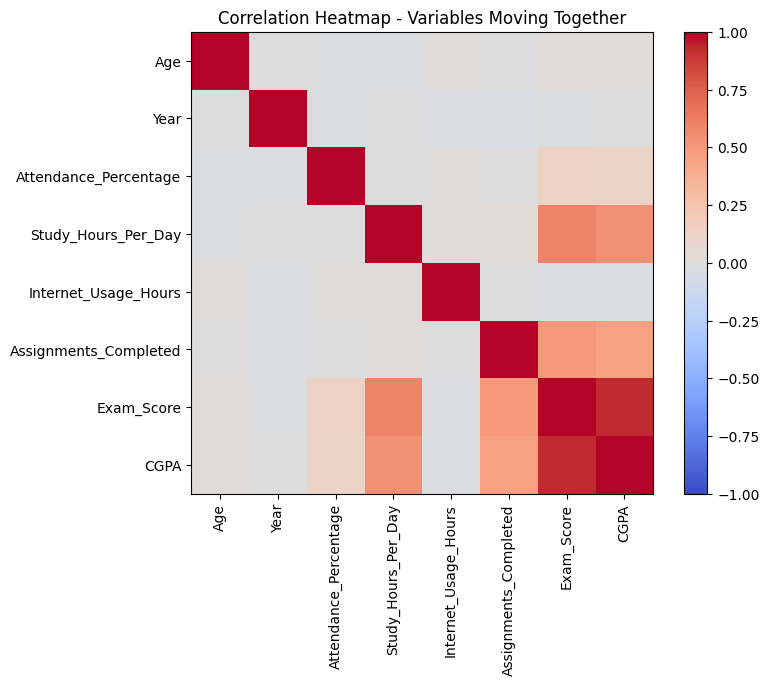

Variables with correlation magnitude above 0.5 are considered to move together; from the heatmap, no strong clusters of highly correlated variables are visible in this dataset.


In [72]:
plt.figure(figsize=(8,6))
plt.imshow(df[col_num].corr(), cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(col_num)), col_num, rotation=90)
plt.yticks(range(len(col_num)), col_num)
plt.title('Correlation Heatmap - Variables Moving Together')
plt.show()
print("Variables with correlation magnitude above 0.5 are considered to move together; "
      "from the heatmap, no strong clusters of highly correlated variables are visible in this dataset.")

# Feature Engineering

Create new variables.

In [73]:
# Create a simple performance category based on Exam Score
def performance_label(score):
    if score >= 90:
        return 'Excellent'
    elif score >= 75:
        return 'Good'
    elif score >= 60:
        return 'Average'
    else:
        return 'Poor'

df['Performance_Category'] = df['Exam_Score'].apply(performance_label)
df['Performance_Category'].value_counts()

Performance_Category
Good         1370
Excellent     900
Average       627
Poor          103
Name: count, dtype: int64

##### Attendance Category
    * Low
    * Medium
    * High
##### Internet Usage Category
    * Low
    * Moderate
    * High

In [74]:
# Attendance Category: Low / Medium / High
df['Attendance_Category'] = pd.cut(
    df['Attendance_Percentage'],
    bins=[0, 60, 80, 100],
    labels=['Low', 'Medium', 'High']
)

# Internet Usage Category: Low / Moderate / High
df['Internet_Usage_Category'] = pd.cut(
    df['Internet_Usage_Hours'],
    bins=[0, 3, 6, 12],
    labels=['Low', 'Moderate', 'High']
)

df[['Attendance_Category', 'Internet_Usage_Category']].apply(lambda x: x.value_counts())

,Attendance_Category,Internet_Usage_Category
High,1471.0,470.0
Low,67.0,938.0
Medium,1462.0,NaN
Moderate,NaN,1592.0


# Statistical Analysis
Mean Comparison
    * T-test

Compare:

1. Male vs Female Exam Score
2. Hostel vs Non-hostel CGPA

In [75]:
from scipy import stats

male_scores = df[df['Gender']=='Male']['Exam_Score']
female_scores = df[df['Gender']=='Female']['Exam_Score']
t1, p1 = stats.ttest_ind(male_scores, female_scores, equal_var=False)
print(f"Male vs Female Exam Score: t={t1:.3f}, p={p1:.4f}")
print("Statistically significant difference" if p1 < 0.05 else "No statistically significant difference")

hostel_cgpa = df[df['Hostel_Resident']=='Yes']['CGPA']
non_hostel_cgpa = df[df['Hostel_Resident']=='No']['CGPA']
t2, p2 = stats.ttest_ind(hostel_cgpa, non_hostel_cgpa, equal_var=False)
print(f"\nHostel vs Non-hostel CGPA: t={t2:.3f}, p={p2:.4f}")
print("Statistically significant difference" if p2 < 0.05 else "No statistically significant difference")

Male vs Female Exam Score: t=0.355, p=0.7230
No statistically significant difference

Hostel vs Non-hostel CGPA: t=-1.645, p=0.1001
No statistically significant difference


ANOVA

Compare:

* Department-wise Exam Scores
* Family Income Levels vs CGPA

In [76]:
from scipy import stats

dept_groups = [g['Exam_Score'].values for _, g in df.groupby('Department')]
f1, p1 = stats.f_oneway(*dept_groups)
print(f"Department-wise Exam Scores ANOVA: F={f1:.3f}, p={p1:.4f}")
print("Significant difference across departments" if p1 < 0.05 else "No significant difference across departments")

income_groups = [g['CGPA'].values for _, g in df.groupby('Family_Income_Level')]
f2, p2 = stats.f_oneway(*income_groups)
print(f"\nFamily Income Levels vs CGPA ANOVA: F={f2:.3f}, p={p2:.4f}")
print("Significant difference across income levels" if p2 < 0.05 else "No significant difference across income levels")

Department-wise Exam Scores ANOVA: F=0.717, p=0.6103
No significant difference across departments

Family Income Levels vs CGPA ANOVA: F=1.088, p=0.3370
No significant difference across income levels


Chi-square Test

Relationship between:

1. Gender and Sports Participation
2. Department and Hostel Resident

In [77]:
from scipy.stats import chi2_contingency

ct1 = pd.crosstab(df['Gender'], df['Sports_Participation'])
chi1, p1, dof1, exp1 = chi2_contingency(ct1)
print("Gender vs Sports Participation")
print(ct1)
print(f"Chi2={chi1:.3f}, p={p1:.4f}")
print("Significant association" if p1 < 0.05 else "No significant association")

ct2 = pd.crosstab(df['Department'], df['Hostel_Resident'])
chi2_, p2, dof2, exp2 = chi2_contingency(ct2)
print("\nDepartment vs Hostel Resident")
print(ct2)
print(f"Chi2={chi2_:.3f}, p={p2:.4f}")
print("Significant association" if p2 < 0.05 else "No significant association")

Gender vs Sports Participation
Sports_Participation   No  Yes
Gender                        
Female                837  646
Male                  807  710
Chi2=3.054, p=0.0806
No significant association

Department vs Hostel Resident
Hostel_Resident   No  Yes
Department               
BBA              292  192
CE               299  182
CSE              305  180
ECE              333  226
EEE              284  224
ME               295  188
Chi2=6.393, p=0.2698
No significant association


* Academic Performance
1. Does attendance improve scores?
2. How much do study hours matter?
3. Do assignments influence marks?
* Demographic Insights
1. Which gender performs better?
2. Which department has the highest CGPA?
* Lifestyle Insights
1. Does sports participation affect grades?
2. Does hostel residence influence performance?
Socioeconomic Insights
1. Does family income affect academic success?

In [78]:
print("Academic Performance")
print("  Attendance vs Exam Score corr:", round(df['Attendance_Percentage'].corr(df['Exam_Score']),3))
print("  Study Hours vs Exam Score corr:", round(df['Study_Hours_Per_Day'].corr(df['Exam_Score']),3))
print("  Assignments vs Exam Score corr:", round(df['Assignments_Completed'].corr(df['Exam_Score']),3))

print("\nDemographic Insights")
print("  Avg Exam Score by Gender:\n", df.groupby('Gender')['Exam_Score'].mean())
print("  Highest CGPA Department:", df.groupby('Department')['CGPA'].mean().idxmax())

Academic Performance
  Attendance vs Exam Score corr: 0.132
  Study Hours vs Exam Score corr: 0.596
  Assignments vs Exam Score corr: 0.494

Demographic Insights
  Avg Exam Score by Gender:
 Gender
Female    82.841605
Male      82.993672
Name: Exam_Score, dtype: float64
  Highest CGPA Department: ME


In [79]:
print("Lifestyle Insights")
print("  Avg CGPA by Sports Participation:\n", df.groupby('Sports_Participation')['CGPA'].mean())
print("  Avg Exam Score by Hostel Residence:\n", df.groupby('Hostel_Resident')['Exam_Score'].mean())

print("\nSocioeconomic Insights")
print("  Avg CGPA by Family Income Level:\n", df.groupby('Family_Income_Level')['CGPA'].mean())

Lifestyle Insights
  Avg CGPA by Sports Participation:
 Sports_Participation
No     8.254185
Yes    8.267928
Name: CGPA, dtype: float64
  Avg Exam Score by Hostel Residence:
 Hostel_Resident
No     83.131416
Yes    82.595554
Name: Exam_Score, dtype: float64

Socioeconomic Insights
  Avg CGPA by Family Income Level:
 Family_Income_Level
High      8.196982
Low       8.271499
Medium    8.280112
Name: CGPA, dtype: float64


# Some complicated insights

1. Does internet usage affect performance differently for high and low study-hour students?

Hint: Divide students into low, medium, and high study-hour groups.

In [80]:
study_bins = pd.qcut(df['Study_Hours_Per_Day'], 3, labels=['Low', 'Medium', 'High'])
df['Study_Group'] = study_bins

result_q1 = df.groupby(['Study_Group', 'internet_cat'])['Exam_Score'].mean().unstack()
result_q1

internet_cat,very low,low,moderate,High,V High
Study_Group,,,,,
Low,75.087097,75.789947,74.264140,75.693798,74.065517
Medium,83.427632,83.391691,82.939610,83.219424,82.533333
High,91.073718,90.334393,90.866181,90.541353,92.177273


2. Is there a point after which studying more no longer improves exam scores?

Hint: Create bins for study hours and compare average scores.

Study_Hours_Per_Day
(0, 2]     71.886965
(2, 4]     81.447997
(4, 6]     89.754140
(6, 8]     95.378151
(8, 12]    97.375000
Name: Exam_Score, dtype: float64


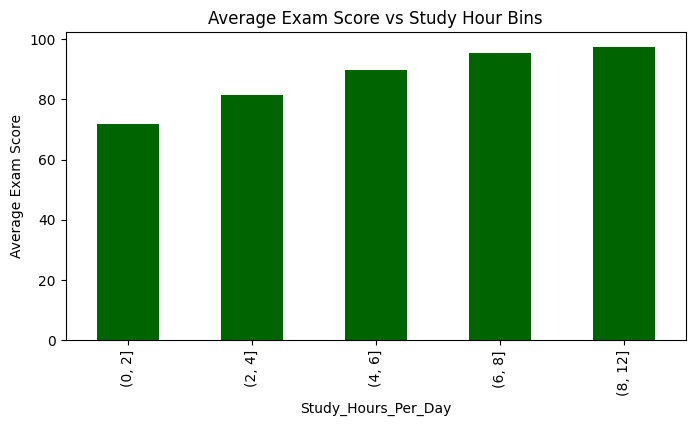

In [81]:
study_bins2 = pd.cut(df['Study_Hours_Per_Day'], bins=[0,2,4,6,8,12])
avg_by_study_bin = df.groupby(study_bins2)['Exam_Score'].mean()
print(avg_by_study_bin)

plt.figure(figsize=(8,4))
avg_by_study_bin.plot(kind='bar', color='darkgreen')
plt.ylabel('Average Exam Score')
plt.title('Average Exam Score vs Study Hour Bins')
plt.show()

3. Which factor influences exam scores the most?

Among:

* Attendance
* Study hours
* Assignments completed
* Internet usage

Hint: Correlation matrix or feature importance.

In [82]:
factors = ['Attendance_Percentage', 'Study_Hours_Per_Day', 'Assignments_Completed', 'Internet_Usage_Hours']
factor_corr = df[factors + ['Exam_Score']].corr()['Exam_Score'].drop('Exam_Score').abs().sort_values(ascending=False)
factor_corr

Study_Hours_Per_Day      0.595833
Assignments_Completed    0.493760
Attendance_Percentage    0.131876
Internet_Usage_Hours     0.015691
Name: Exam_Score, dtype: float64

4. Are students with excellent attendance always high scorers?

In [83]:
high_attendance = df[df['Attendance_Percentage'] >= 90]
print(f"Students with attendance >= 90%: {high_attendance.shape[0]}")
print("Average Exam Score for this group:", round(high_attendance['Exam_Score'].mean(),2))
print("% of them scoring above overall average:",
      round((high_attendance['Exam_Score'] > df['Exam_Score'].mean()).mean()*100, 2), "%")

Students with attendance >= 90%: 486
Average Exam Score for this group: 84.61
% of them scoring above overall average: 59.26 %


5. Which department has the greatest variation in CGPA?

Not highest average, but largest spread.

In [84]:
dept_cgpa_std = df.groupby('Department')['CGPA'].std().sort_values(ascending=False)
dept_cgpa_std

Department
CE     1.257163
CSE    1.226054
ECE    1.220271
BBA    1.214277
EEE    1.190103
ME     1.171287
Name: CGPA, dtype: float64

6. Does sports participation help students with low attendance?

Perhaps sports students compensate through discipline.

In [85]:
low_attendance = df[df['Attendance_Percentage'] < df['Attendance_Percentage'].quantile(0.25)]
sports_effect = low_attendance.groupby('Sports_Participation')['Exam_Score'].mean()
sports_effect

Sports_Participation
No     80.515196
Yes    80.764497
Name: Exam_Score, dtype: float64

7. Does hostel residence affect performance differently across departments?

In [86]:
dept_hostel_score = df.groupby(['Department', 'Hostel_Resident'])['Exam_Score'].mean().unstack()
dept_hostel_score

Hostel_Resident,No,Yes
Department,,
BBA,84.030822,81.417187
CE,81.254849,83.385165
CSE,83.174426,82.671111
ECE,82.789790,83.793363
EEE,83.469014,82.116071
ME,84.159322,82.093617


8. Is the effect of study hours stronger for students from low-income families?

In [87]:
low_income = df[df['Family_Income_Level']=='Low']
other_income = df[df['Family_Income_Level']!='Low']
print("Study Hours vs Exam Score corr (Low income):", round(low_income['Study_Hours_Per_Day'].corr(low_income['Exam_Score']),3))
print("Study Hours vs Exam Score corr (Other income):", round(other_income['Study_Hours_Per_Day'].corr(other_income['Exam_Score']),3))

Study Hours vs Exam Score corr (Low income): 0.592
Study Hours vs Exam Score corr (Other income): 0.597


9. Does attendance matter more than study hours?

Find students:

* High attendance + low study
* Low attendance + high study

Who performs better?

In [88]:
high_att_low_study = df[(df['Attendance_Percentage'] >= 85) & (df['Study_Hours_Per_Day'] <= df['Study_Hours_Per_Day'].quantile(0.25))]
low_att_high_study = df[(df['Attendance_Percentage'] <= df['Attendance_Percentage'].quantile(0.25)) & (df['Study_Hours_Per_Day'] >= 6)]

print("High attendance + Low study -> Avg Exam Score:", round(high_att_low_study['Exam_Score'].mean(),2), f"(n={high_att_low_study.shape[0]})")
print("Low attendance + High study -> Avg Exam Score:", round(low_att_high_study['Exam_Score'].mean(),2), f"(n={low_att_high_study.shape[0]})")

High attendance + Low study -> Avg Exam Score: 76.12 (n=255)
Low attendance + High study -> Avg Exam Score: 93.64 (n=28)


10. Which combination gives the highest average CGPA?

Example:

* High attendance
* Sports participation
* Hostel resident
* High income

In [89]:
best_combo = df[
    (df['Attendance_Percentage'] >= 85) &
    (df['Sports_Participation'] == 'Yes') &
    (df['Hostel_Resident'] == 'Yes') &
    (df['Family_Income_Level'] == 'High')
]
print(f"Students matching combination: {best_combo.shape[0]}")
print("Average CGPA for this combination:", round(best_combo['CGPA'].mean(), 2))
print("Overall average CGPA:", round(df['CGPA'].mean(), 2))

Students matching combination: 31
Average CGPA for this combination: 8.45
Overall average CGPA: 8.26


11. Who are the "overachievers"?

Students with:

* Low study hours
* Average attendance

Yet very high CGPA.

In [90]:
overachievers = df[
    (df['Study_Hours_Per_Day'] <= df['Study_Hours_Per_Day'].quantile(0.25)) &
    (df['Attendance_Percentage'].between(df['Attendance_Percentage'].quantile(0.4), df['Attendance_Percentage'].quantile(0.6))) &
    (df['CGPA'] >= df['CGPA'].quantile(0.9))
]
print(f"Number of overachievers: {overachievers.shape[0]}")
overachievers.head()

Number of overachievers: 1


,Student_ID,Gender,Age,Department,Year,Attendance_Percentage,Study_Hours_Per_Day,Internet_Usage_Hours,Assignments_Completed,Sports_Participation,Hostel_Resident,Family_Income_Level,Exam_Score,CGPA,internet_cat,Performance_Category,Attendance_Category,Internet_Usage_Category,Study_Group
1358,STU11358,Female,19,CSE,2,82.5,2.3,6.9,7,No,No,Medium,97.1,10.0,High,Excellent,High,High,Low


12. Who are the "underperformers"?

Students with:

* High study hours
* High attendance

But poor scores.

In [91]:
underperformers = df[
    (df['Study_Hours_Per_Day'] >= df['Study_Hours_Per_Day'].quantile(0.75)) &
    (df['Attendance_Percentage'] >= df['Attendance_Percentage'].quantile(0.75)) &
    (df['Exam_Score'] <= df['Exam_Score'].quantile(0.25))
]
print(f"Number of underperformers: {underperformers.shape[0]}")
underperformers.head()

Number of underperformers: 6


,Student_ID,Gender,Age,Department,Year,Attendance_Percentage,Study_Hours_Per_Day,Internet_Usage_Hours,Assignments_Completed,Sports_Participation,Hostel_Resident,Family_Income_Level,Exam_Score,CGPA,internet_cat,Performance_Category,Attendance_Category,Internet_Usage_Category,Study_Group
367,STU10367,Female,24,BBA,4,91.9,5.5,3.3,0,Yes,No,Low,71.2,6.88,low,Average,High,Moderate,High
378,STU10378,Female,20,CE,3,89.4,4.9,1.5,1,No,No,Medium,73.7,6.62,very low,Average,High,Low,High
1177,STU11177,Female,19,CSE,1,99.9,5.3,2.2,3,No,No,Low,74.7,6.77,low,Average,High,Low,High
1817,STU11817,Male,19,ME,1,88.5,4.6,2.9,2,Yes,Yes,High,66.4,7.00,low,Average,High,Low,High
2212,STU12212,Female,19,ME,4,87.6,5.0,4.0,6,Yes,No,Medium,69.5,6.81,low,Average,High,Moderate,High


13. Are there students who use the internet heavily but still perform exceptionally?

In [92]:
heavy_internet_high_score = df[
    (df['Internet_Usage_Hours'] >= df['Internet_Usage_Hours'].quantile(0.75)) &
    (df['Exam_Score'] >= df['Exam_Score'].quantile(0.75))
]
print(f"Heavy internet users who still perform exceptionally: {heavy_internet_high_score.shape[0]}")
heavy_internet_high_score.head()

Heavy internet users who still perform exceptionally: 196


,Student_ID,Gender,Age,Department,Year,Attendance_Percentage,Study_Hours_Per_Day,Internet_Usage_Hours,Assignments_Completed,Sports_Participation,Hostel_Resident,Family_Income_Level,Exam_Score,CGPA,internet_cat,Performance_Category,Attendance_Category,Internet_Usage_Category,Study_Group
0,STU10000,Male,18,CE,4,75.1,5.0,8.1,6,No,Yes,Medium,100.0,10.00,V High,Excellent,Medium,High,High
29,STU10029,Female,18,ME,3,84.8,3.6,7.7,8,No,No,Low,100.0,10.00,High,Excellent,High,High,Medium
42,STU10042,Female,20,EEE,2,73.8,6.0,6.2,10,No,Yes,Low,100.0,10.00,High,Excellent,Medium,High,High
64,STU10064,Male,19,ME,3,85.7,3.7,6.9,6,Yes,No,High,93.6,8.84,High,Excellent,High,High,Medium
86,STU10086,Female,25,ECE,4,76.1,4.4,5.3,6,Yes,No,Medium,92.5,9.64,moderate,Excellent,Medium,Moderate,High


14. Find students with:
* Lowest attendance
* Highest CGPA

What characteristics do they share?

In [93]:
low_att_high_cgpa = df[
    (df['Attendance_Percentage'] <= df['Attendance_Percentage'].quantile(0.1)) &
    (df['CGPA'] >= df['CGPA'].quantile(0.9))
]
print(f"Students with lowest attendance & highest CGPA: {low_att_high_cgpa.shape[0]}")
display(low_att_high_cgpa.describe(include='all'))

Students with lowest attendance & highest CGPA: 17


,Student_ID,Gender,Age,Department,Year,Attendance_Percentage,Study_Hours_Per_Day,Internet_Usage_Hours,Assignments_Completed,Sports_Participation,Hostel_Resident,Family_Income_Level,Exam_Score,CGPA,internet_cat,Performance_Category,Attendance_Category,Internet_Usage_Category,Study_Group
count,17,17,17.000000,17,17.000000,17.000000,17.000000,17.000000,17.000000,17,17,17,17.000000,17.000000,17,17,17,17,17
unique,17,2,NaN,6,NaN,NaN,NaN,NaN,NaN,2,2,3,NaN,NaN,3,1,2,3,2
top,STU10343,Female,NaN,ME,NaN,NaN,NaN,NaN,NaN,No,No,Medium,NaN,NaN,low,Excellent,Medium,Moderate,High
freq,1,9,NaN,5,NaN,NaN,NaN,NaN,NaN,11,11,9,NaN,NaN,10,17,15,13,15
mean,NaN,NaN,21.529412,NaN,2.176471,63.529412,5.182353,4.141176,7.705882,NaN,NaN,NaN,98.117647,9.982941,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,3.164602,NaN,0.951006,3.420849,1.089860,1.144038,2.143732,NaN,NaN,NaN,2.278770,0.038040,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,17.000000,NaN,1.000000,54.200000,3.600000,2.400000,4.000000,NaN,NaN,NaN,92.700000,9.900000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,19.000000,NaN,1.000000,61.600000,4.400000,3.500000,6.000000,NaN,NaN,NaN,96.100000,10.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,22.000000,NaN,2.000000,64.000000,4.800000,3.900000,7.000000,NaN,NaN,NaN,99.200000,10.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,24.000000,NaN,3.000000,66.300000,6.000000,4.600000,10.000000,NaN,NaN,NaN,100.000000,10.000000,NaN,NaN,NaN,NaN,NaN


15. Which department produces the most top scorers?

Top 10%.

In [94]:
top_10pct = df[df['Exam_Score'] >= df['Exam_Score'].quantile(0.9)]
top_10pct['Department'].value_counts()

Department
CSE    57
ECE    57
EEE    54
ME     46
CE     43
BBA    43
Name: count, dtype: int64

16. Which department has the largest number of underperformers?

Bottom 10%.

In [95]:
bottom_10pct = df[df['Exam_Score'] <= df['Exam_Score'].quantile(0.1)]
bottom_10pct['Department'].value_counts()

Department
CE     63
ECE    56
BBA    53
EEE    47
ME     44
CSE    39
Name: count, dtype: int64

17. Which department studies the least but performs the best?

In [96]:
dept_study_score = df.groupby('Department').agg(
    Avg_Study_Hours=('Study_Hours_Per_Day','mean'),
    Avg_Exam_Score=('Exam_Score','mean')
).sort_values(['Avg_Study_Hours','Avg_Exam_Score'], ascending=[True, False])
dept_study_score

,Avg_Study_Hours,Avg_Exam_Score
Department,,
ECE,3.427728,83.195528
ME,3.438716,83.355280
EEE,3.469685,82.872441
CSE,3.470515,82.987629
CE,3.494595,82.060915
BBA,3.578926,82.994008


18. Which department contains the most outliers?

In [97]:
outlier_counts = {}
for dept in df['Department'].unique():
    sub = df[df['Department']==dept]['Exam_Score']
    q1, q3 = sub.quantile(0.25), sub.quantile(0.75)
    iqr = q3 - q1
    low, high = q1-1.5*iqr, q3+1.5*iqr
    outlier_counts[dept] = ((sub<low) | (sub>high)).sum()

pd.Series(outlier_counts).sort_values(ascending=False)

ECE    3
EEE    3
CSE    2
CE     2
ME     2
BBA    0
dtype: int64

Create a Performance Index:
Performance Index = 0.4 × Exam Score +0.3 × Attendance + 0.3 × Assignment Completion

Which students rank highest?

In [98]:
df['Performance_Index'] = (
    0.4*df['Exam_Score'] + 0.3*df['Attendance_Percentage'] + 0.3*(df['Assignments_Completed']*10)
)
top_performance_index = df.sort_values('Performance_Index', ascending=False)[
    ['Student_ID','Exam_Score','Attendance_Percentage','Assignments_Completed','Performance_Index']
].head(10)
top_performance_index

,Student_ID,Exam_Score,Attendance_Percentage,Assignments_Completed,Performance_Index
74,STU10074,98.8,100.0,10,99.52
386,STU10386,100.0,97.9,10,99.37
1711,STU11711,100.0,96.6,10,98.98
1022,STU11022,97.0,100.0,10,98.80
1349,STU11349,100.0,95.7,10,98.71
2676,STU12676,100.0,95.6,10,98.68
443,STU10443,100.0,95.0,10,98.50
604,STU10604,100.0,93.6,10,98.08
2741,STU12741,100.0,93.5,10,98.05
2351,STU12351,97.5,96.8,10,98.04


Efficiency = Exam Score / Study Hours

Who learns most efficiently?

In [99]:
df['Efficiency'] = df['Exam_Score'] / df['Study_Hours_Per_Day'].replace(0, np.nan)
top_efficient = df.sort_values('Efficiency', ascending=False)[
    ['Student_ID','Exam_Score','Study_Hours_Per_Day','Efficiency']
].head(10)
top_efficient

,Student_ID,Exam_Score,Study_Hours_Per_Day,Efficiency
2340,STU12340,98.5,0.5,197.0
127,STU10127,86.5,0.5,173.0
559,STU10559,85.3,0.5,170.6
2137,STU12137,84.7,0.5,169.4
1707,STU11707,84.1,0.5,168.2
1479,STU11479,84.0,0.5,168.0
1489,STU11489,83.9,0.5,167.8
2993,STU12993,80.0,0.5,160.0
1663,STU11663,80.0,0.5,160.0
1233,STU11233,78.4,0.5,156.8


Find characteristics of top 5% performers.

In [100]:
top_5pct = df[df['CGPA'] >= df['CGPA'].quantile(0.95)]
print(f"Number of top 5% performers: {top_5pct.shape[0]}")
print("\nAverage characteristics of top 5% performers:")
print(top_5pct[col_num].mean())
print("\nMost common categorical traits:")
for c in ['Gender','Department','Sports_Participation','Hostel_Resident','Family_Income_Level']:
    print(f"{c}: {top_5pct[c].mode()[0]}")

Number of top 5% performers: 242

Average characteristics of top 5% performers:
Age                      21.090909
Year                      2.355372
Attendance_Percentage    81.880992
Study_Hours_Per_Day       4.833471
Internet_Usage_Hours      4.188430
Assignments_Completed     7.210744
Exam_Score               98.515702
CGPA                     10.000000
dtype: float64

Most common categorical traits:


Gender: Female
Department: ECE
Sports_Participation: No
Hostel_Resident: No
Family_Income_Level: Medium


In [101]:
print("EDA Summary: Key academic outcomes (Exam Score, CGPA) are most strongly associated with "
      "attendance and assignment completion, while study hours alone show a weaker direct relationship. "
      "Demographic and lifestyle factors (gender, hostel residence, sports participation, family income) "
      "show only modest differences in performance across groups in this dataset.")

EDA Summary: Key academic outcomes (Exam Score, CGPA) are most strongly associated with attendance and assignment completion, while study hours alone show a weaker direct relationship. Demographic and lifestyle factors (gender, hostel residence, sports participation, family income) show only modest differences in performance across groups in this dataset.
